Part 2.1 - BloodMNIST DCGAN

In [ ]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.9 MB/s eta 0:00:00


1. Imports & Setup

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader
from scipy import linalg
import warnings

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Device: cuda


2. Load and Explore BloodMNIST

In [ ]:
from medmnist import BloodMNIST, INFO

info = INFO['bloodmnist']
CLASS_NAMES = list(info['label'].values())
N_CLASSES   = len(CLASS_NAMES)
print(f'Classes ({N_CLASSES}):', CLASS_NAMES)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])
train_ds = BloodMNIST(split='train', transform=transform, download=True, size=28)
print('Dataset size:', len(train_ds))


Classes (8): ['basophil', 'eosinophil', 'erythroblast', 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


100%|██████████| 35.5M/35.5M [00:01<00:00, 20.1MB/s]


Dataset size: 11959


3. Class Distribution and Sample Images

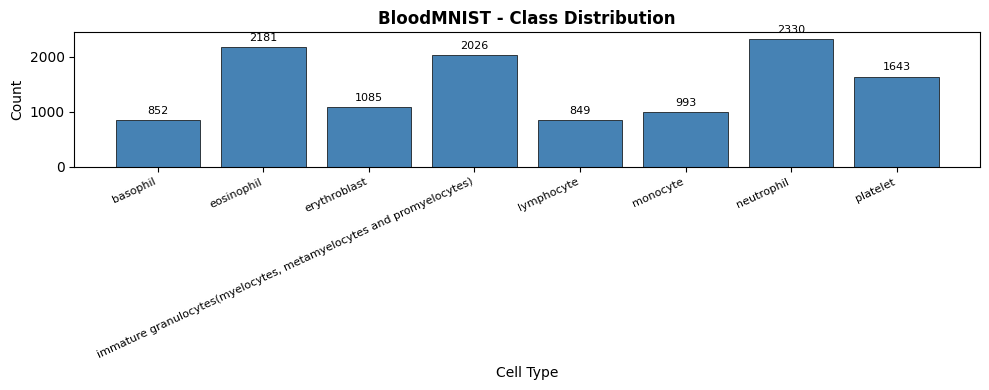

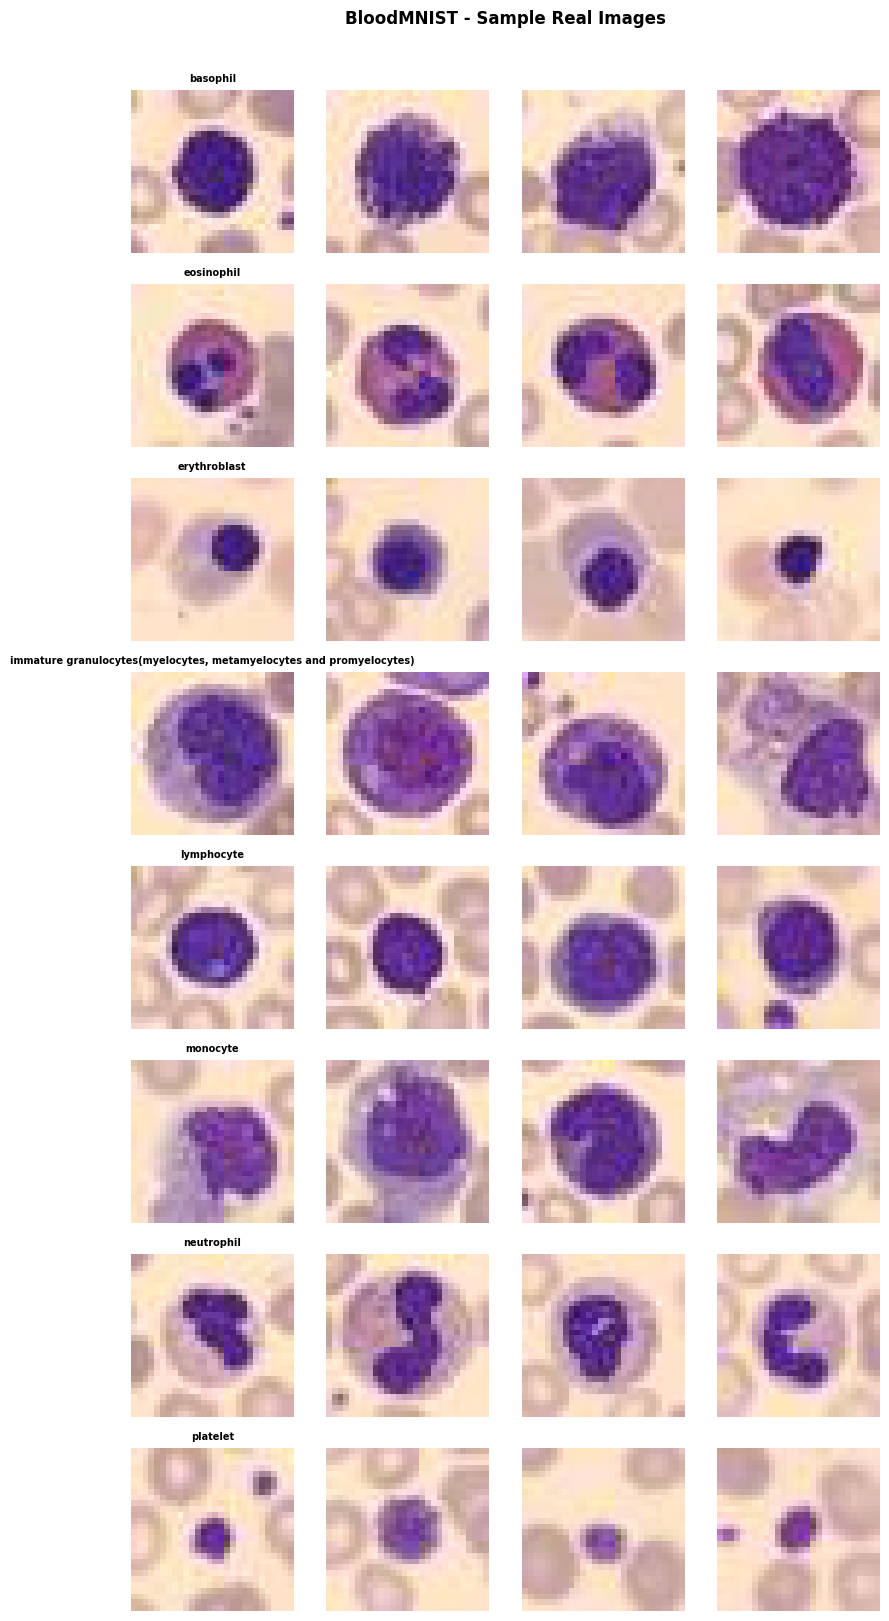

In [ ]:
labels_all = np.array([train_ds[i][1].item() for i in range(len(train_ds))])
counts = [(CLASS_NAMES[c], (labels_all==c).sum()) for c in range(N_CLASSES)]

fig, ax = plt.subplots(figsize=(10,4))
names  = [c[0] for c in counts]
values = [c[1] for c in counts]
bars = ax.bar(names, values, color='steelblue', edgecolor='black', linewidth=0.5)
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_title('BloodMNIST - Class Distribution', fontweight='bold')
ax.set_xlabel('Cell Type'); ax.set_ylabel('Count')
plt.xticks(rotation=25, ha='right', fontsize=8)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(N_CLASSES, 4, figsize=(8, N_CLASSES*2))
for cls in range(N_CLASSES):
    idxs = np.where(labels_all==cls)[0][:4]
    for j, idx in enumerate(idxs):
        img = (train_ds[idx][0]*0.5+0.5).permute(1,2,0).numpy().clip(0,1)
        axes[cls,j].imshow(img); axes[cls,j].axis('off')
        if j==0: axes[cls,j].set_title(CLASS_NAMES[cls], fontsize=7, fontweight='bold')
plt.suptitle('BloodMNIST - Sample Real Images', fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


4. DCGAN Model Definitions

In [ ]:
class DCGANGenerator(nn.Module):
    def __init__(self, latent_dim=100, channels=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256*7*7),
            nn.Unflatten(1,(256,7,7)),
            nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256,128,4,2,1),  # 7->14
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128,channels,4,2,1),  # 14->28
            nn.Tanh(),
        )
    def forward(self,z): return self.net(z)


class DCGANDiscriminator(nn.Module):
    def __init__(self, channels=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(channels,128,4,2,1), nn.LeakyReLU(0.2),
            nn.Conv2d(128,256,4,2,1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
            nn.Flatten(),
        )
        self.classifier = nn.Sequential(nn.Linear(256*7*7,1), nn.Sigmoid())
    def forward(self,x): return self.classifier(self.features(x))
    def extract_features(self,x): return self.features(x)


def init_weights(m):
    if isinstance(m,(nn.Conv2d,nn.ConvTranspose2d,nn.Linear)):
        nn.init.normal_(m.weight,0.0,0.02)
        if m.bias is not None: nn.init.zeros_(m.bias)
    elif isinstance(m,nn.BatchNorm2d):
        nn.init.normal_(m.weight,1.0,0.02); nn.init.zeros_(m.bias)


LATENT_DIM    = 100
generator     = DCGANGenerator(LATENT_DIM, channels=3).to(DEVICE)
discriminator = DCGANDiscriminator(channels=3).to(DEVICE)
generator.apply(init_weights); discriminator.apply(init_weights)
print(f'Generator     : {sum(p.numel() for p in generator.parameters()):,} params')
print(f'Discriminator : {sum(p.numel() for p in discriminator.parameters()):,} params')


Generator     : 1,798,275 params
Discriminator : 543,873 params


5. Training Setup

In [ ]:
BATCH_SIZE  = 128  # larger batch = better GPU utilisation
LR          = 0.0002
BETAS       = (0.5, 0.999)
NUM_EPOCHS  = 50

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          drop_last=True, num_workers=2, pin_memory=True)

loss_fn = nn.BCELoss()
opt_G   = torch.optim.Adam(generator.parameters(),     lr=LR,       betas=BETAS)
opt_D   = torch.optim.Adam(discriminator.parameters(), lr=LR*0.5,   betas=BETAS)

fixed_noise = torch.randn(32, LATENT_DIM, device=DEVICE)
print(f'Batches/epoch: {len(train_loader)} | Epochs: {NUM_EPOCHS} | Batch: {BATCH_SIZE}')


Batches/epoch: 93 | Epochs: 50 | Batch: 128


6. Train DCGAN

In [ ]:
def train_dcgan(generator, discriminator, loader, opt_G, opt_D,
                loss_fn, num_epochs, latent_dim, device, fixed_noise,
                print_every=5, snapshot_epochs=None):
    g_losses, d_losses, snapshots = [], [], {}
    for epoch in range(num_epochs):
        g_epoch, d_epoch, n = 0.0, 0.0, 0
        for real_imgs, _ in loader:
            real_imgs = real_imgs.to(device, non_blocking=True)
            bs = real_imgs.size(0)
            # Label smoothing: real=0.9 prevents discriminator overconfidence
            real_labels = torch.full((bs,1), 0.9, device=device)
            fake_labels = torch.zeros(bs, 1, device=device)

            # Discriminator update
            z         = torch.randn(bs, latent_dim, device=device)
            fake_imgs = generator(z).detach()
            loss_d    = loss_fn(discriminator(real_imgs), real_labels) + \
                        loss_fn(discriminator(fake_imgs), fake_labels)
            opt_D.zero_grad(); loss_d.backward(); opt_D.step()

            # Generator update
            z         = torch.randn(bs, latent_dim, device=device)
            fake_imgs = generator(z)
            loss_g    = loss_fn(discriminator(fake_imgs), torch.ones(bs,1,device=device))
            opt_G.zero_grad(); loss_g.backward(); opt_G.step()

            g_epoch += loss_g.item(); d_epoch += loss_d.item(); n += 1

        g_losses.append(g_epoch/n); d_losses.append(d_epoch/n)

        if snapshot_epochs and (epoch+1) in snapshot_epochs:
            generator.eval()
            with torch.no_grad(): imgs = generator(fixed_noise).cpu()
            generator.train()
            snapshots[epoch+1] = imgs

        if (epoch+1) % print_every == 0:
            print(f'Epoch {epoch+1:3d}/{num_epochs} | Loss G: {g_losses[-1]:.4f} | Loss D: {d_losses[-1]:.4f}')

    return g_losses, d_losses, snapshots


SNAPSHOT_EPOCHS = [10, 25, 50]
g_losses, d_losses, snapshots = train_dcgan(
    generator, discriminator, train_loader, opt_G, opt_D, loss_fn,
    NUM_EPOCHS, LATENT_DIM, DEVICE, fixed_noise,
    print_every=5, snapshot_epochs=SNAPSHOT_EPOCHS
)


Epoch   5/50 | Loss G: 1.2508 | Loss D: 1.2018
Epoch  10/50 | Loss G: 1.3900 | Loss D: 1.1555
Epoch  15/50 | Loss G: 1.4388 | Loss D: 1.1000
Epoch  20/50 | Loss G: 1.5113 | Loss D: 1.0140
Epoch  25/50 | Loss G: 1.5856 | Loss D: 1.0315
Epoch  30/50 | Loss G: 1.6214 | Loss D: 1.0609
Epoch  35/50 | Loss G: 1.6583 | Loss D: 1.0092
Epoch  40/50 | Loss G: 1.6388 | Loss D: 0.9972
Epoch  45/50 | Loss G: 1.8019 | Loss D: 1.0114
Epoch  50/50 | Loss G: 1.6695 | Loss D: 1.0173


7. Loss Curves

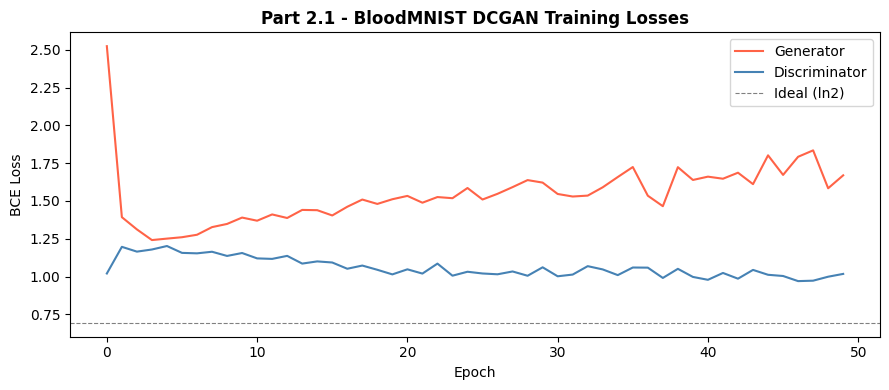

In [ ]:
import math
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(g_losses, label='Generator',     color='tomato',    linewidth=1.5)
ax.plot(d_losses, label='Discriminator', color='steelblue', linewidth=1.5)
ax.axhline(y=math.log(2), color='grey', linestyle='--', linewidth=0.8, label='Ideal (ln2)')
ax.set_title('Part 2.1 - BloodMNIST DCGAN Training Losses', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss'); ax.legend()
plt.tight_layout(); plt.show()


8. Training Progression Snapshots

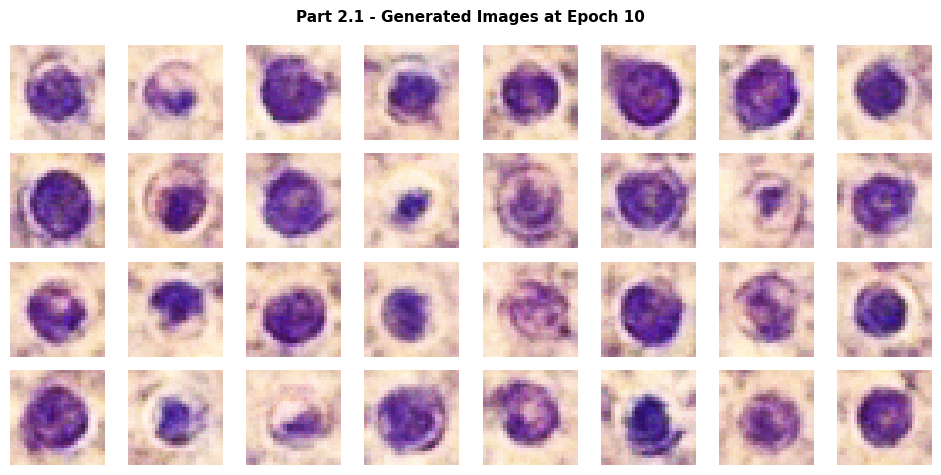

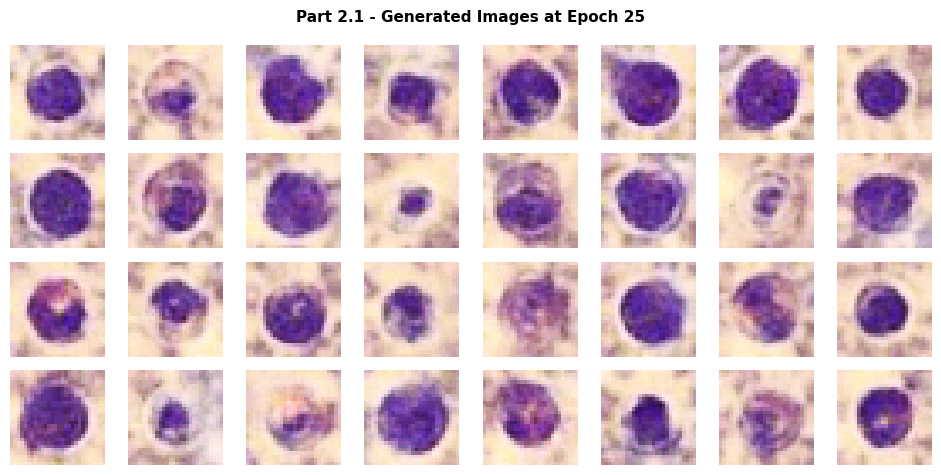

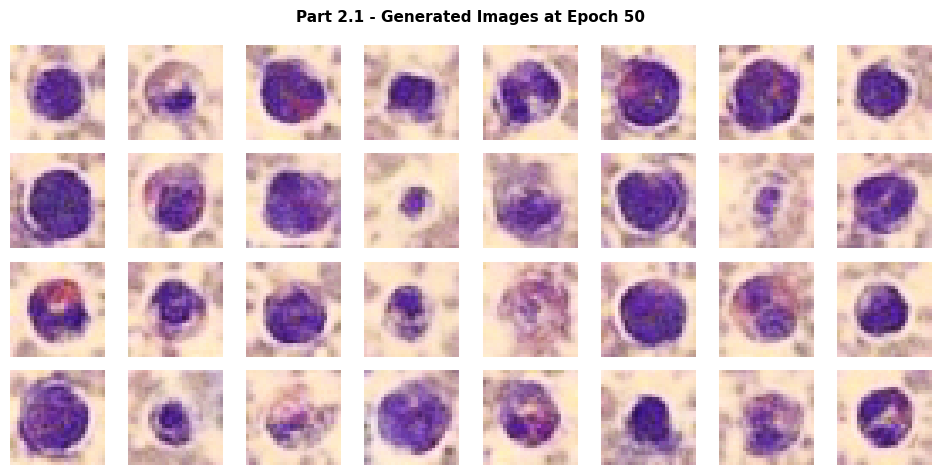

In [ ]:
def show_image_grid(imgs_tensor, title, n_cols=8):
    imgs   = (imgs_tensor*0.5+0.5).clamp(0,1)
    n      = min(len(imgs),32)
    n_rows = (n+n_cols-1)//n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*1.2, n_rows*1.2))
    axes = axes.flatten()
    for i in range(len(axes)):
        if i<n: axes[i].imshow(imgs[i].permute(1,2,0).numpy())
        axes[i].axis('off')
    plt.suptitle(title, fontweight='bold', fontsize=11)
    plt.tight_layout(); plt.show()

for ep in SNAPSHOT_EPOCHS:
    if ep in snapshots:
        show_image_grid(snapshots[ep], f'Part 2.1 - Generated Images at Epoch {ep}')


9. Real vs Generated Comparison

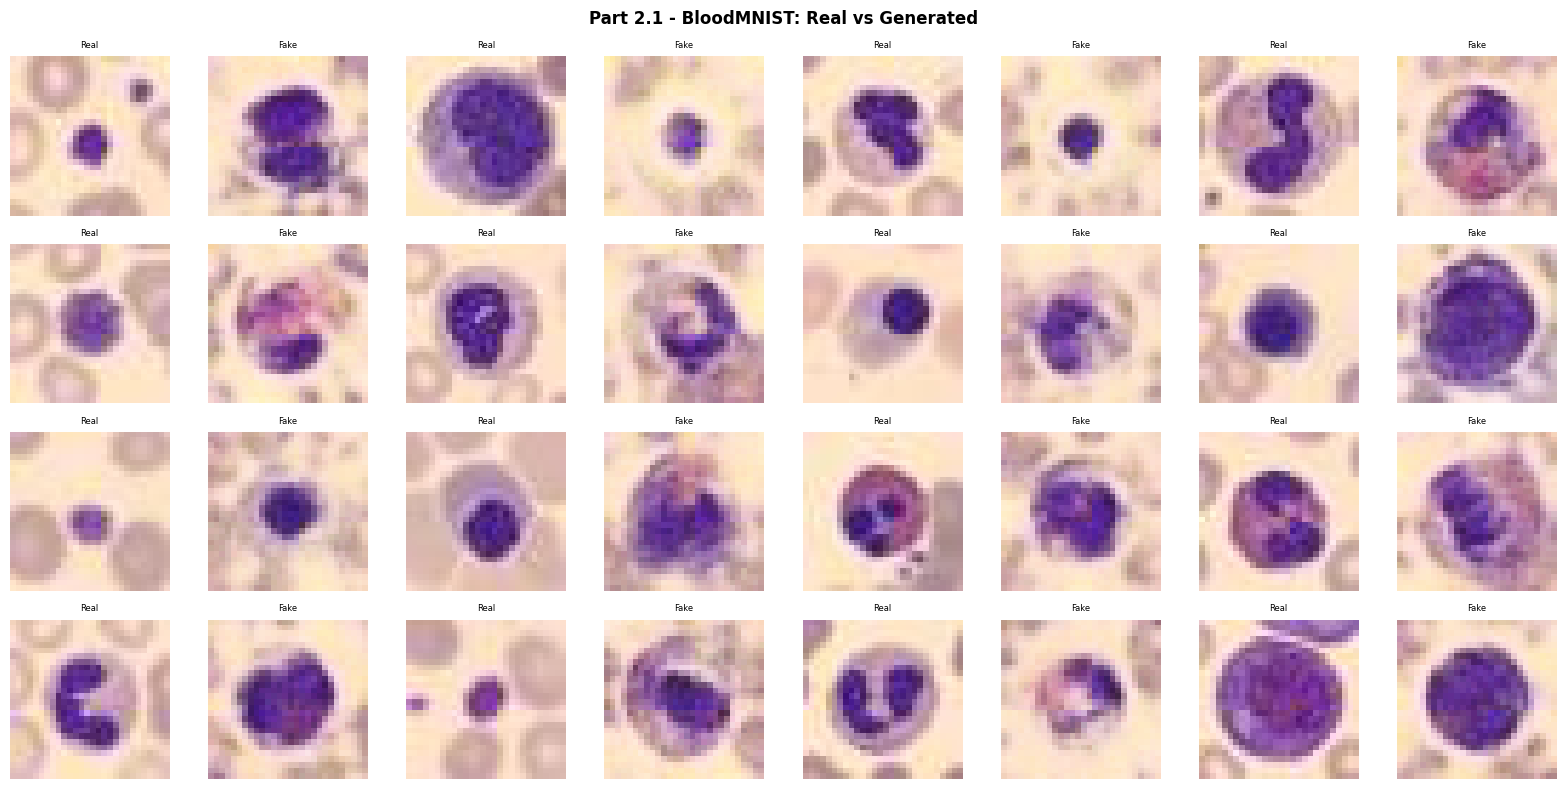

In [ ]:
generator.eval()
with torch.no_grad():
    final_fake = generator(torch.randn(32,LATENT_DIM,device=DEVICE)).cpu()
generator.train()

real_sample_imgs = torch.stack([train_ds[i][0] for i in range(32)])

fig, axes = plt.subplots(4, 8, figsize=(16,8))
axes = axes.flatten()
for i in range(32):
    ax = axes[i]
    if i%2==0:
        img = (real_sample_imgs[i//2]*0.5+0.5).clamp(0,1).permute(1,2,0).numpy()
        ax.imshow(img); ax.set_title('Real', fontsize=6)
    else:
        img = (final_fake[i//2]*0.5+0.5).clamp(0,1).permute(1,2,0).numpy()
        ax.imshow(img); ax.set_title('Fake', fontsize=6)
    ax.axis('off')
plt.suptitle('Part 2.1 - BloodMNIST: Real vs Generated', fontweight='bold')
plt.tight_layout(); plt.show()


10. FID Score

In [ ]:
def extract_disc_features(discriminator, imgs_tensor, device, batch_size=128):
    discriminator.eval()
    all_feats = []
    with torch.no_grad():
        for i in range(0, len(imgs_tensor), batch_size):
            batch = imgs_tensor[i:i+batch_size].to(device, non_blocking=True)
            feats = discriminator.extract_features(batch)
            # Average pool 256x7x7 -> 256 dims to keep sqrtm fast
            feats = feats.view(feats.size(0),256,-1).mean(dim=2)
            all_feats.append(feats.cpu().numpy())
    discriminator.train()
    return np.concatenate(all_feats, axis=0)


def compute_fid(real_features, fake_features):
    mu_r, mu_f = np.mean(real_features, axis=0), np.mean(fake_features, axis=0)
    sigma_r    = np.cov(real_features, rowvar=False)
    sigma_f    = np.cov(fake_features, rowvar=False)
    diff       = mu_r - mu_f
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        covmean, _ = linalg.sqrtm(sigma_r @ sigma_f, disp=False)
    if np.iscomplexobj(covmean): covmean = covmean.real
    return float(diff@diff + np.trace(sigma_r + sigma_f - 2*covmean))


N_FID = 1000
real_imgs_fid = torch.stack([train_ds[i][0] for i in range(N_FID)])
generator.eval()
with torch.no_grad():
    fake_imgs_fid = generator(torch.randn(N_FID,LATENT_DIM,device=DEVICE)).cpu()
generator.train()

real_feats = extract_disc_features(discriminator, real_imgs_fid, DEVICE)
fake_feats = extract_disc_features(discriminator, fake_imgs_fid, DEVICE)
fid_score  = compute_fid(real_feats, fake_feats)
print(f'FID Score: {fid_score:.4f}')
print(f'Interpretation: FID=0 perfect | FID<50 good | FID>100 poor')
print(f'Our FID: {fid_score:.2f}')


FID Score: 0.5378
Interpretation: FID=0 perfect | FID<50 good | FID>100 poor
Our FID: 0.54


11. Results Summary

In [ ]:
print(f'Dataset      : BloodMNIST, {len(train_ds)} images, 8 classes')
print(f'Architecture : DCGAN (ConvTranspose2d generator, Conv2d discriminator)')
print(f'Latent dim   : {LATENT_DIM} | Epochs: {NUM_EPOCHS} | Batch: {BATCH_SIZE}')
print(f'Final Loss G : {g_losses[-1]:.4f} | Final Loss D: {d_losses[-1]:.4f}')
print(f'FID Score    : {fid_score:.4f}')

Dataset      : BloodMNIST, 11959 images, 8 classes
Architecture : DCGAN (ConvTranspose2d generator, Conv2d discriminator)
Latent dim   : 100 | Epochs: 50 | Batch: 128
Final Loss G : 1.6695 | Final Loss D: 1.0173
FID Score    : 0.5378
